In [2]:
from langgraph.graph import StateGraph, END
import random
from typing import Dict, List, TypedDict

In [3]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [4]:
def greeting_node(state:AgentState) -> str:
    """This node is decribes the greetings from the user and the system"""
    state['name'] = f"Hi There , {state['name']}"
    state['counter'] = 0
    
    return state 

def random_node(state:AgentState) -> str:
    """This node is decribes the random number generation"""
    state['number'].append(random.randint(0, 10))
    state['counter'] += 1
    
    return state

def should_continue(state:AgentState) -> str:
    """This function is used to decide what to do next"""
    
    if state['counter']<5:
        print('ENTERING THE LOOP', state['counter'])
        return 'loop'
    else:
        return 'exit'



In [6]:
graph = StateGraph(AgentState)

graph.add_node('greeting', greeting_node)
graph.add_node('random', random_node)
graph.add_edge('greeting', 'random')

graph.add_conditional_edges(
    'random',
    should_continue,
    {
        'loop': 'random', # Self-looping back to same node
        'exit': END    #End the graph execution
    }
)

graph.set_entry_point('greeting')

app = graph.compile()


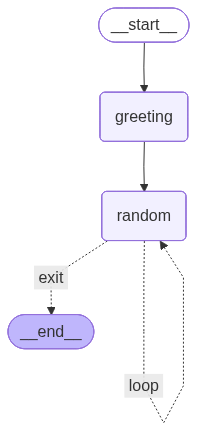

In [7]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [9]:
app.invoke({'name':'Dinesh', 'number':[], 'counter':-1})

ENTERING THE LOOP 1
ENTERING THE LOOP 2
ENTERING THE LOOP 3
ENTERING THE LOOP 4


{'name': 'Hi There , Dinesh', 'number': [2, 0, 10, 1, 4], 'counter': 5}

EXCERCISE GRAPH


In [11]:
from typing import TypedDict,Dict,List
from langgraph.graph import StateGraph, END, START

In [12]:
import random

class GameState(TypedDict):
    player_name: str
    target_number: int
    guesses: List[int]
    attempts: int
    hint: str
    lower_bound: int
    upper_bound: int

In [13]:
def setup_node(state:GameState) -> GameState:
    """Initialize the game with a random target number"""
    state['player_name'] = f"Welcome {state['player_name']} to the Number Guessing Game!"
    state['target_number'] = random.randint(1,20)
    state['guesses'] = []
    state['attempts'] = 0
    state['hint'] = 'Game started! Guess a number between 1 and 20'
    state['lower_bound'] = 1
    state['upper_bound'] = 20
    print(f"{state['player_name']} The game has begun. I'm thinking of a number between 1 and 20")
    return state

In [14]:
def guess_node(state: GameState) -> GameState:
    """Generate a smarter guess based on previous hints"""
    
    possible_guesses = [i for i in range(state["lower_bound"], state["upper_bound"] + 1) if i not in state["guesses"]]
    if possible_guesses:
        guess = random.choice(possible_guesses)
    else:
        
        guess = random.randint(state["lower_bound"], state["upper_bound"])
    
    state["guesses"].append(guess)
    state["attempts"] += 1
    print(f"Attempt {state['attempts']}: Guessing {guess} (Current range: {state['lower_bound']}-{state['upper_bound']})")
    return state

In [15]:
def hint_node(state: GameState) -> GameState:
    """Here we provide a hint based on the last guess and update the bounds"""
    latest_guess = state["guesses"][-1]
    target = state["target_number"]
    
    if latest_guess < target:
        state["hint"] = f"The number {latest_guess} is too low. Try higher!"
        
        state["lower_bound"] = max(state["lower_bound"], latest_guess + 1)
        print(f"Hint: {state['hint']}")
        
    elif latest_guess > target:
        state["hint"] = f"The number {latest_guess} is too high. Try lower!"
      
        state["upper_bound"] = min(state["upper_bound"], latest_guess - 1)
        print(f"Hint: {state['hint']}")
    else:
        state["hint"] = f"Correct! You found the number {target} in {state['attempts']} attempts."
        print(f"Success! {state['hint']}")
    
    return state

In [16]:
def should_continue(state: GameState) -> str:
    """Determine if we should continue guessing or end the game"""
    
    # There are 2 end conditions - either 7 is reached or the correct number is guessed
    
    latest_guess = state["guesses"][-1]
    if latest_guess == state["target_number"]:
        print(f"GAME OVER: Number found!")
        return "end"
    elif state["attempts"] >= 7:
        print(f"GAME OVER: Maximum attempts reached! The number was {state['target_number']}")
        return "end"
    else:
        print(f"CONTINUING: {state['attempts']}/7 attempts used")
        return "continue"

In [17]:
graph = StateGraph(GameState)
graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)
graph.add_node("hint_node", hint_node)  


graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint_node")  


graph.add_conditional_edges(
    "hint_node", 
    should_continue,
    {
        "continue": "guess",
        "end": END
    }
)

graph.set_entry_point("setup")
app = graph.compile()

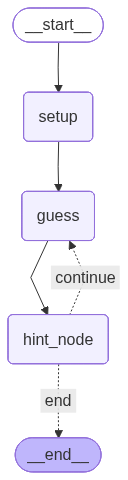

In [18]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
result = app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})

Welcome Student to the Number Guessing Game! The game has begun. I'm thinking of a number between 1 and 20
Attempt 1: Guessing 2 (Current range: 1-20)
Hint: The number 2 is too low. Try higher!
CONTINUING: 1/7 attempts used
Attempt 2: Guessing 7 (Current range: 3-20)
Hint: The number 7 is too low. Try higher!
CONTINUING: 2/7 attempts used
Attempt 3: Guessing 14 (Current range: 8-20)
Hint: The number 14 is too high. Try lower!
CONTINUING: 3/7 attempts used
Attempt 4: Guessing 10 (Current range: 8-13)
Hint: The number 10 is too low. Try higher!
CONTINUING: 4/7 attempts used
Attempt 5: Guessing 13 (Current range: 11-13)
Hint: The number 13 is too high. Try lower!
CONTINUING: 5/7 attempts used
Attempt 6: Guessing 11 (Current range: 11-12)
Hint: The number 11 is too low. Try higher!
CONTINUING: 6/7 attempts used
Attempt 7: Guessing 12 (Current range: 12-12)
Success! Correct! You found the number 12 in 7 attempts.
GAME OVER: Number found!
